
# Triadic Cell Notebook v33
## KRRB-native breathing controller with SILR, Samson, and AHRC

This notebook turns the v32 breathing beam into an explicit KRRB controller.

The stack is:

- **KRRB**
  - branch ontology
  - keep, spawn, merge, prune, collapse

- **SILR**
  - leak / anomaly gate
  - z-score branch health test

- **Samson**
  - timing / breath law
  - adaptive step size toward the Mark-1 target

- **AHRC**
  - address expansion law
  - expand branch frame when ambiguity remains too dense

This notebook asks a direct question:

Can the beam be improved if branch survival is not only rank-based,
but also governed by:
- branch leak
- branch timing
- branch alias density
- late coherent collapse



## Practical meaning

This is still runtime control, not base-model training.

The claim is not that this is a finished AI architecture.
The claim is narrower and stronger:

- v31 showed inward recursion can improve closure but not identity.
- v32 showed inhale/exhale branch competition can improve identity.
- v33 tests whether the branch layer becomes cleaner when it is given
  explicit KRRB semantics and support laws.

The core outputs are:

- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `krrb_trace_df`

The most important targets are:

- `krrb_accuracy`
- `krrb_vs_beam_gain`
- `partial_krrb_accuracy`
- `krrb_missing_drop`


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape: np.ndarray, local_mold: np.ndarray, alpha: float = 0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls: int):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Directional basis


In [3]:

raw_basis = np.array([
    [1.0, 0.0, 0.6, 0.2, 0.0, 0.3],
    [0.2, 1.0, 0.0, 0.6, 0.2, 0.0],
    [0.0, 0.2, 1.0, 0.0, 0.6, 0.2],
    [0.6, 0.0, 0.2, 1.0, 0.0, 0.6],
    [0.0, 0.6, 0.2, 0.0, 1.0, 0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)


## Query corruption


In [4]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls: int, mode: str):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.40
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])

    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.58 * target + 0.42 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])

    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Core decomposition


In [5]:

def directional_coeffs(x: np.ndarray):
    return U @ x

def reconstruct_from_coeffs(c: np.ndarray):
    return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query: np.ndarray, target: np.ndarray):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    active_dirs = int(np.sum(np.abs(aq) > 0.10))
    boundary_complexity = int(np.sum(np.abs(at) > 0.12))
    boundary_eff = max(1.0, boundary_complexity / 2.0)
    nyquist_score = float(active_dirs / boundary_eff)

    return {
        "R": R,
        "M": M,
        "E": E,
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
        "aligned_ratio": float(aligned_energy / total_energy),
        "nyquist_score": nyquist_score,
    }



## Candidate evaluation


In [6]:

def triadic_evaluate(query: np.ndarray, cls: int):
    s0, s1, s2 = chains[cls]
    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.35 * split["missing_ratio"]
        + 0.20 * split["excess_ratio"]
        + 0.25 * (1.0 - retrieve_fit)
        + 0.20 * max(0.0, 1.0 - split["nyquist_score"])
    )

    closure_score = (
        0.60 * retrieve_fit
        + 0.35 * split["aligned_ratio"]
        - 0.90 * split["missing_ratio"]
        - 0.45 * split["excess_ratio"]
        - 0.50 * bridge_energy
    )

    declaration_score = closure_score + 0.18 * min(split["nyquist_score"], 2.0)

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "closure_score": float(closure_score),
        "declaration_score": float(declaration_score),
        "R": split["R"],
        "M": split["M"],
        "E": split["E"],
        "missing_ratio": split["missing_ratio"],
        "excess_ratio": split["excess_ratio"],
        "nyquist_score": split["nyquist_score"],
        "declared_value": projected2,
    }

def triadic_query(query: np.ndarray):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin



## Calibration


In [7]:

rows = []
n_per_class = 700

for cls in range(n_classes):
    for _ in range(n_per_class):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(cls, mode)
        best, _, _ = triadic_query(q)
        rows.append({
            "query": q,
            "true_class": cls,
            "query_mode": mode,
            "declaration_score": best["declaration_score"],
        })

world_df = pd.DataFrame(rows)

perm = rng.permutation(len(world_df))
split = int(0.5 * len(world_df))
cal_df = world_df.iloc[perm[:split]].reset_index(drop=True)
eval_df = world_df.iloc[perm[split:]].reset_index(drop=True)

target_retrieve_fraction = 0.35
retrieve_threshold = float(cal_df["declaration_score"].quantile(1.0 - target_retrieve_fraction))
retrieve_threshold


1.2780704554873628


## Field emission

This is the same field object as before, but it exposes everything needed
for KRRB-level branch accounting.


In [8]:

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def produce_fields_for_class(query: np.ndarray, cls: int, threshold: float):
    ev = triadic_evaluate(query, cls)
    all_results = [triadic_evaluate(query, c) for c in range(n_classes)]
    all_results = sorted(all_results, key=lambda r: r["declaration_score"], reverse=True)

    if ev["class"] == all_results[0]["class"]:
        margin = float(ev["declaration_score"] - all_results[1]["declaration_score"])
    else:
        margin = float(ev["declaration_score"] - all_results[0]["declaration_score"])

    mode = "retrieve" if ev["declaration_score"] >= threshold else "grow"

    closure_permission = sigmoid(8.0 * (ev["declaration_score"] - threshold))
    nyquist_permission = sigmoid(5.0 * (ev["nyquist_score"] - 1.0))
    margin_permission = sigmoid(10.0 * (margin - 0.05))
    permission = float(closure_permission * nyquist_permission * margin_permission)

    retrieve_mask = normalize01(ev["R"] * permission)
    missing_mask = normalize01(ev["M"])
    contradiction_mask = normalize01(ev["E"])
    signed_correction = ev["M"] - 0.6 * ev["E"]
    fold_field = normalize01(0.5 + 0.5 * signed_correction)

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    return {
        "predicted_class": cls,
        "mode": mode,
        "margin": margin,
        "retrieve_fit": ev["retrieve_fit"],
        "bridge_energy": ev["bridge_energy"],
        "closure_score": ev["closure_score"],
        "declaration_score": ev["declaration_score"],
        "nyquist_score": ev["nyquist_score"],
        "permission": permission,
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "fold_field": fold_field,
        "signed_correction": signed_correction,
        "declared_value": ev["declared_value"],
    }

def produce_fields_best(query: np.ndarray, threshold: float):
    best, _, _ = triadic_query(query)
    return produce_fields_for_class(query, best["class"], threshold)



## KRRB support laws

### SILR
Scale-invariant leakage under z-score gating.

### Samson
Adaptive timing law. We use the Mark-1 target in normalized form:
a healthy branch should not be too stagnant or too explosive.

### AHRC
If the beam remains crowded or low-separation after a cycle, expand the frame.
Here frame expansion means temporarily increasing beam width.


In [9]:

MARK1 = np.pi / 9.0

def silr_score(values: np.ndarray, x: float):
    mu = float(np.mean(values))
    sd = float(np.std(values) + 1e-8)
    return float((x - mu) / sd)

def samson_step_scale(missing_mass: float, contradiction_mass: float):
    # normalized surrogate around a "healthy" internal tension target
    h = 0.65 * missing_mass + 0.35 * contradiction_mass
    delta = h - MARK1
    # larger when far from target, smaller when close
    step = 0.25 + 0.35 * np.tanh(abs(delta) * 3.0)
    return float(step), float(delta)

def ahrc_expand_needed(rank_scores: list[float], margins: list[float]):
    if len(rank_scores) < 2:
        return False
    spread = max(rank_scores) - min(rank_scores)
    margin_mean = float(np.mean(margins)) if len(margins) else 0.0
    return (spread < 0.12) or (margin_mean < 0.10)



## Baselines

Single-branch recursion and v32-style breathing beam are kept for comparison.


In [10]:

def recursive_fold_branch(query: np.ndarray, cls: int, threshold: float, max_steps: int = 8, step_size: float = 0.45, damping: float = 0.85):
    q = query.copy()
    hist_rows = []

    for step in range(max_steps):
        f = produce_fields_for_class(q, cls, threshold)
        hist_rows.append({
            "step": step,
            "class": cls,
            "mode": f["mode"],
            "missing_mass": float(f["missing_mask"].mean()),
            "retrieve_mass": float(f["retrieve_mask"].mean()),
            "permission": f["permission"],
        })
        update = step_size * f["signed_correction"]
        q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

    final_fields = produce_fields_for_class(q, cls, threshold)
    return q, pd.DataFrame(hist_rows), final_fields

def single_branch_recursive(query: np.ndarray, threshold: float):
    best, _, _ = triadic_query(query)
    return recursive_fold_branch(query, best["class"], threshold)

def top_candidate_classes(query: np.ndarray, k: int = 3):
    results = [triadic_evaluate(query, c) for c in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    return [r["class"] for r in results[:k]]

def breathing_beam(query: np.ndarray, threshold: float, beam_width: int = 3, cycles: int = 4, exhale_steps: int = 2, step_size: float = 0.45, damping: float = 0.85):
    init_classes = top_candidate_classes(query, k=beam_width)
    beam = [{"cls": cls, "query": query.copy(), "spawn_from": -1} for cls in init_classes]
    trace_rows = []

    for cycle in range(cycles):
        expanded = []

        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]

            for _ in range(exhale_steps):
                f = produce_fields_for_class(q, cls, threshold)
                update = step_size * f["signed_correction"]
                q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

            expanded.append({"cls": cls, "query": q.copy(), "spawn_from": branch["spawn_from"]})

            for alt_cls in top_candidate_classes(q, k=min(2, n_classes)):
                if alt_cls != cls:
                    expanded.append({"cls": alt_cls, "query": q.copy(), "spawn_from": cls})

        scored = []
        for item in expanded:
            f = produce_fields_for_class(item["query"], item["cls"], threshold)
            rank_score = (
                0.70 * f["declaration_score"]
                + 0.20 * f["permission"]
                - 0.35 * float(f["missing_mask"].mean())
                - 0.10 * float(f["contradiction_mask"].mean())
            )
            scored.append({
                **item,
                "rank_score": float(rank_score),
                "mode": f["mode"],
                "declaration_score": f["declaration_score"],
                "missing_mass": float(f["missing_mask"].mean()),
                "retrieve_mass": float(f["retrieve_mask"].mean()),
                "permission": f["permission"],
            })

        best_per_class = {}
        for item in scored:
            cls = item["cls"]
            if cls not in best_per_class or item["rank_score"] > best_per_class[cls]["rank_score"]:
                best_per_class[cls] = item

        beam = sorted(best_per_class.values(), key=lambda x: x["rank_score"], reverse=True)[:beam_width]

        for rank, item in enumerate(beam):
            trace_rows.append({
                "cycle": cycle,
                "beam_rank": rank,
                "class": item["cls"],
                "mode": item["mode"],
                "rank_score": item["rank_score"],
                "declaration_score": item["declaration_score"],
                "missing_mass": item["missing_mass"],
                "retrieve_mass": item["retrieve_mass"],
                "permission": item["permission"],
                "spawn_from": item["spawn_from"],
            })

    final_best = beam[0]
    final_fields = produce_fields_for_class(final_best["query"], final_best["cls"], threshold)
    return final_best["query"], pd.DataFrame(trace_rows), final_fields



## KRRB-native controller

Branch state carries:
- current query
- current class
- SILR leak score
- Samson timing
- AHRC frame expansion
- KRRB keep / merge / retire logic


In [11]:

def krrb_controller(
    query: np.ndarray,
    threshold: float,
    beam_width: int = 3,
    cycles: int = 4,
    exhale_steps: int = 2,
    damping: float = 0.85,
):
    init_classes = top_candidate_classes(query, k=beam_width)
    beam = [{
        "cls": cls,
        "query": query.copy(),
        "spawn_from": -1,
        "stagnation": 0,
    } for cls in init_classes]

    trace_rows = []

    for cycle in range(cycles):
        expanded = []

        # inhale/exhale current branches
        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]
            prev_missing = None
            stagnation = branch["stagnation"]

            for _ in range(exhale_steps):
                f = produce_fields_for_class(q, cls, threshold)
                missing_mass = float(f["missing_mask"].mean())
                contradiction_mass = float(f["contradiction_mask"].mean())

                step_scale, samson_delta = samson_step_scale(missing_mass, contradiction_mass)
                update = step_scale * f["signed_correction"]
                q_new = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

                if prev_missing is not None and abs(prev_missing - missing_mass) < 1e-4:
                    stagnation += 1
                prev_missing = missing_mass
                q = q_new

            expanded.append({
                "cls": cls,
                "query": q.copy(),
                "spawn_from": branch["spawn_from"],
                "stagnation": stagnation,
            })

            # inhale alternatives only if branch is ambiguous or leaking
            alt_classes = top_candidate_classes(q, k=min(3, n_classes))
            for alt_cls in alt_classes:
                if alt_cls != cls:
                    expanded.append({
                        "cls": alt_cls,
                        "query": q.copy(),
                        "spawn_from": cls,
                        "stagnation": 0,
                    })

        # score all branches
        scored = []
        prelim_missing = []

        tmp_fields = []
        for item in expanded:
            f = produce_fields_for_class(item["query"], item["cls"], threshold)
            prelim_missing.append(float(f["missing_mask"].mean()))
            tmp_fields.append((item, f))

        missing_arr = np.array(prelim_missing, dtype=float)

        for item, f in tmp_fields:
            missing_mass = float(f["missing_mask"].mean())
            contradiction_mass = float(f["contradiction_mask"].mean())
            retrieve_mass = float(f["retrieve_mask"].mean())
            z_leak = silr_score(missing_arr, missing_mass)
            step_scale, samson_delta = samson_step_scale(missing_mass, contradiction_mass)

            rank_score = (
                0.60 * f["declaration_score"]
                + 0.18 * f["permission"]
                + 0.10 * retrieve_mass
                - 0.28 * missing_mass
                - 0.12 * contradiction_mass
                - 0.08 * max(z_leak, 0.0)
                - 0.05 * item["stagnation"]
            )

            scored.append({
                **item,
                "mode": f["mode"],
                "rank_score": float(rank_score),
                "declaration_score": f["declaration_score"],
                "missing_mass": missing_mass,
                "retrieve_mass": retrieve_mass,
                "contradiction_mass": contradiction_mass,
                "permission": f["permission"],
                "samson_step": step_scale,
                "samson_delta": samson_delta,
                "silr_z": float(z_leak),
            })

        # keep best instance per class
        best_per_class = {}
        for item in scored:
            cls = item["cls"]
            if cls not in best_per_class or item["rank_score"] > best_per_class[cls]["rank_score"]:
                best_per_class[cls] = item

        beam = list(best_per_class.values())
        beam = sorted(beam, key=lambda x: x["rank_score"], reverse=True)

        # AHRC: expand frame if the current beam is too crowded
        margins = []
        for i in range(len(beam) - 1):
            margins.append(beam[i]["rank_score"] - beam[i + 1]["rank_score"])
        if ahrc_expand_needed([b["rank_score"] for b in beam], margins):
            local_width = min(len(beam), beam_width + 1)
        else:
            local_width = beam_width

        # SILR retirement: remove extreme leaking branches unless they are the winner
        filtered = []
        for idx, item in enumerate(beam):
            if idx == 0:
                filtered.append(item)
            else:
                if item["silr_z"] < 1.4:
                    filtered.append(item)

        beam = filtered[:local_width]
        beam = beam[:beam_width]

        for rank, item in enumerate(beam):
            trace_rows.append({
                "cycle": cycle,
                "beam_rank": rank,
                "class": item["cls"],
                "mode": item["mode"],
                "rank_score": item["rank_score"],
                "declaration_score": item["declaration_score"],
                "missing_mass": item["missing_mass"],
                "retrieve_mass": item["retrieve_mass"],
                "contradiction_mass": item["contradiction_mass"],
                "permission": item["permission"],
                "silr_z": item["silr_z"],
                "samson_step": item["samson_step"],
                "samson_delta": item["samson_delta"],
                "spawn_from": item["spawn_from"],
                "stagnation": item["stagnation"],
            })

    final_best = beam[0]
    final_fields = produce_fields_for_class(final_best["query"], final_best["cls"], threshold)
    return final_best["query"], pd.DataFrame(trace_rows), final_fields



## Single example


In [12]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

q_single, single_trace_df, single_final = single_branch_recursive(q0, retrieve_threshold)
q_beam, beam_trace_df, beam_final = breathing_beam(
    q0, retrieve_threshold, beam_width=3, cycles=4, exhale_steps=2, damping=0.85
)
q_krrb, krrb_trace_df, krrb_final = krrb_controller(
    q0, retrieve_threshold, beam_width=3, cycles=4, exhale_steps=2, damping=0.85
)

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "single_final_class": single_final["predicted_class"],
    "beam_final_class": beam_final["predicted_class"],
    "krrb_final_class": krrb_final["predicted_class"],
    "single_missing_mass": float(single_final["missing_mask"].mean()),
    "beam_missing_mass": float(beam_final["missing_mask"].mean()),
    "krrb_missing_mass": float(krrb_final["missing_mask"].mean()),
}])
single_example


,true_class,query_mode,single_final_class,beam_final_class,krrb_final_class,single_missing_mass,beam_missing_mass,krrb_missing_mass
0,1,partial,3,3,3,0.95307,0.95307,0.93462


In [13]:

krrb_trace_df.head(12)


,cycle,beam_rank,class,mode,rank_score,declaration_score,missing_mass,retrieve_mass,contradiction_mass,permission,silr_z,samson_step,samson_delta,spawn_from,stagnation
0,0,0,3,grow,-0.027603,0.536400,0.997845,0.002155,0.030423,2.621103e-03,0.838532,0.505797,0.310181,-1,0
1,0,1,1,grow,-0.285258,-0.081153,0.666667,0.095571,0.078801,6.642611e-08,-1.334078,0.363223,0.111848,-1,1
2,0,2,0,grow,-0.286477,0.204719,0.999989,0.000011,0.092583,3.057142e-05,0.852601,0.516557,0.333331,-1,1
3,1,0,3,grow,0.042253,0.691167,0.990547,0.009453,0.028512,8.987369e-03,1.177941,0.503117,0.304769,-1,0
4,1,1,1,grow,-0.187405,0.153261,0.666666,0.162950,0.074925,2.230883e-06,-1.229215,0.361945,0.110491,-1,2
5,1,2,0,grow,-0.233327,0.427360,0.999623,0.000377,0.086614,7.694711e-04,1.245395,0.515525,0.331004,-1,2
6,2,0,3,grow,0.124725,0.806434,0.971411,0.028589,0.026733,2.229877e-02,1.135072,0.496389,0.291707,-1,0
7,2,1,1,grow,-0.127348,0.335354,0.666653,0.166453,0.071247,3.804155e-05,-1.022350,0.360722,0.109195,-1,3
8,2,2,0,grow,-0.139982,0.589550,0.997538,0.002462,0.081042,3.777997e-03,1.320032,0.514041,0.327699,-1,2
9,3,0,3,grow,0.210091,0.894287,0.934620,0.065380,0.025092,4.402938e-02,0.953004,0.482737,0.267219,-1,0



## Compare first pass vs single branch vs breathing beam vs KRRB


In [14]:

rows_compare = []

for _, row in eval_df.iterrows():
    q = row["query"]
    true_class = int(row["true_class"])
    query_mode = row["query_mode"]

    first = produce_fields_best(q, retrieve_threshold)
    _, _, single_final = single_branch_recursive(q, retrieve_threshold)
    _, _, beam_final = breathing_beam(
        q, retrieve_threshold, beam_width=3, cycles=4, exhale_steps=2, damping=0.85
    )
    _, _, krrb_final = krrb_controller(
        q, retrieve_threshold, beam_width=3, cycles=4, exhale_steps=2, damping=0.85
    )

    rows_compare.append({
        "true_class": true_class,
        "query_mode": query_mode,
        "first_correct": int(first["predicted_class"] == true_class),
        "single_correct": int(single_final["predicted_class"] == true_class),
        "beam_correct": int(beam_final["predicted_class"] == true_class),
        "krrb_correct": int(krrb_final["predicted_class"] == true_class),

        "first_missing_mass": float(first["missing_mask"].mean()),
        "single_missing_mass": float(single_final["missing_mask"].mean()),
        "beam_missing_mass": float(beam_final["missing_mask"].mean()),
        "krrb_missing_mass": float(krrb_final["missing_mask"].mean()),

        "first_retrieve_mass": float(first["retrieve_mask"].mean()),
        "single_retrieve_mass": float(single_final["retrieve_mask"].mean()),
        "beam_retrieve_mass": float(beam_final["retrieve_mask"].mean()),
        "krrb_retrieve_mass": float(krrb_final["retrieve_mask"].mean()),
    })

compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_correct,single_correct,beam_correct,krrb_correct,first_missing_mass,single_missing_mass,beam_missing_mass,krrb_missing_mass,first_retrieve_mass,single_retrieve_mass,beam_retrieve_mass,krrb_retrieve_mass
0,0,existing,1,1,1,1,0.155701,0.096915,0.099667,0.101866,0.844299,0.903085,0.900333,0.898134
1,1,noisy,1,1,1,1,0.361475,0.317034,0.317034,0.324825,0.638524,0.682966,0.682966,0.675175
2,1,inverse_hint,1,1,1,1,0.660515,0.544234,0.544234,0.582226,0.339482,0.455766,0.455766,0.417774
3,1,inverse_hint,1,1,1,1,0.395642,0.214208,0.214208,0.263822,0.437690,0.619125,0.619125,0.569511
4,2,inverse_hint,0,0,0,0,0.495890,0.434498,0.434498,0.467413,0.504106,0.565501,0.565501,0.532586



## Core comparison


In [15]:

compare_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "single_branch_accuracy": float(compare_df["single_correct"].mean()),
    "breathing_beam_accuracy": float(compare_df["beam_correct"].mean()),
    "krrb_accuracy": float(compare_df["krrb_correct"].mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "single_branch_missing_mass": float(compare_df["single_missing_mass"].mean()),
    "breathing_beam_missing_mass": float(compare_df["beam_missing_mass"].mean()),
    "krrb_missing_mass": float(compare_df["krrb_missing_mass"].mean()),
}])
compare_summary


,first_pass_accuracy,single_branch_accuracy,breathing_beam_accuracy,krrb_accuracy,first_pass_missing_mass,single_branch_missing_mass,breathing_beam_missing_mass,krrb_missing_mass
0,0.872143,0.872143,0.88,0.877143,0.425414,0.335766,0.309323,0.31901


In [16]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct",
        "single_correct",
        "beam_correct",
        "krrb_correct",
        "first_missing_mass",
        "single_missing_mass",
        "beam_missing_mass",
        "krrb_missing_mass",
        "first_retrieve_mass",
        "single_retrieve_mass",
        "beam_retrieve_mass",
        "krrb_retrieve_mass",
    ]]
    .mean()
    .reset_index()
)

by_mode_compare["krrb_vs_first_gain"] = by_mode_compare["krrb_correct"] - by_mode_compare["first_correct"]
by_mode_compare["krrb_vs_beam_gain"] = by_mode_compare["krrb_correct"] - by_mode_compare["beam_correct"]
by_mode_compare["krrb_missing_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["krrb_missing_mass"]

by_mode_compare = by_mode_compare.sort_values("krrb_vs_first_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,single_correct,beam_correct,krrb_correct,first_missing_mass,single_missing_mass,beam_missing_mass,krrb_missing_mass,first_retrieve_mass,single_retrieve_mass,beam_retrieve_mass,krrb_retrieve_mass,krrb_vs_first_gain,krrb_vs_beam_gain,krrb_missing_drop
4,partial,0.620155,0.620155,0.635659,0.635659,0.662506,0.567453,0.509968,0.501157,0.336988,0.431251,0.480121,0.493117,0.015504,0.000000,0.161349
0,ambiguous,0.978355,0.978355,0.991342,0.982684,0.619463,0.437277,0.432045,0.480329,0.371157,0.554786,0.556411,0.508126,0.004329,-0.008658,0.139134
1,existing,1.000000,1.000000,1.000000,1.000000,0.105301,0.081290,0.068652,0.069215,0.890964,0.914975,0.920610,0.922848,0.000000,0.000000,0.036086
2,inverse_hint,0.807143,0.807143,0.821429,0.807143,0.582822,0.463633,0.449368,0.480356,0.402877,0.508985,0.522060,0.493452,0.000000,-0.014286,0.102466
3,noisy,1.000000,1.000000,1.000000,1.000000,0.269847,0.194834,0.170075,0.174564,0.723135,0.798733,0.819984,0.816079,0.000000,0.000000,0.095283



## Partial-only focus


In [17]:

partial_df = compare_df[compare_df["query_mode"] == "partial"].copy()

partial_summary = pd.DataFrame([{
    "partial_first_accuracy": float(partial_df["first_correct"].mean()),
    "partial_single_accuracy": float(partial_df["single_correct"].mean()),
    "partial_beam_accuracy": float(partial_df["beam_correct"].mean()),
    "partial_krrb_accuracy": float(partial_df["krrb_correct"].mean()),
    "partial_first_missing_mass": float(partial_df["first_missing_mass"].mean()),
    "partial_beam_missing_mass": float(partial_df["beam_missing_mass"].mean()),
    "partial_krrb_missing_mass": float(partial_df["krrb_missing_mass"].mean()),
    "partial_first_retrieve_mass": float(partial_df["first_retrieve_mass"].mean()),
    "partial_beam_retrieve_mass": float(partial_df["beam_retrieve_mass"].mean()),
    "partial_krrb_retrieve_mass": float(partial_df["krrb_retrieve_mass"].mean()),
}])
partial_summary


,partial_first_accuracy,partial_single_accuracy,partial_beam_accuracy,partial_krrb_accuracy,partial_first_missing_mass,partial_beam_missing_mass,partial_krrb_missing_mass,partial_first_retrieve_mass,partial_beam_retrieve_mass,partial_krrb_retrieve_mass
0,0.620155,0.620155,0.635659,0.635659,0.662506,0.509968,0.501157,0.336988,0.480121,0.493117



## Visual readout


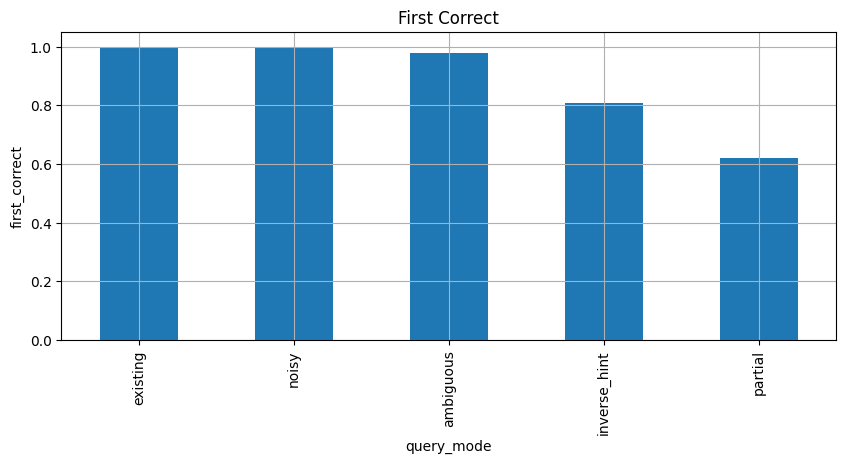

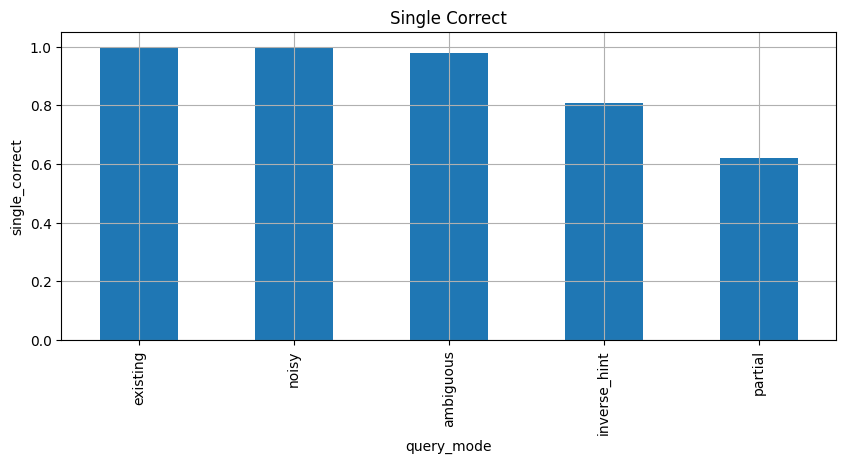

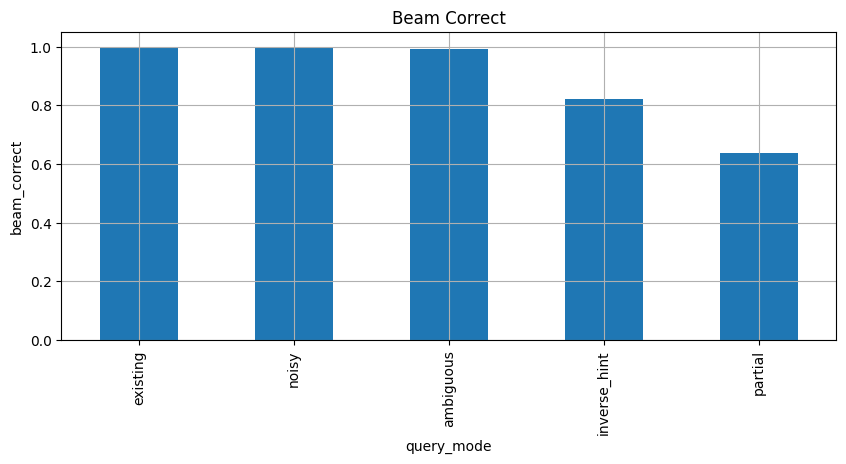

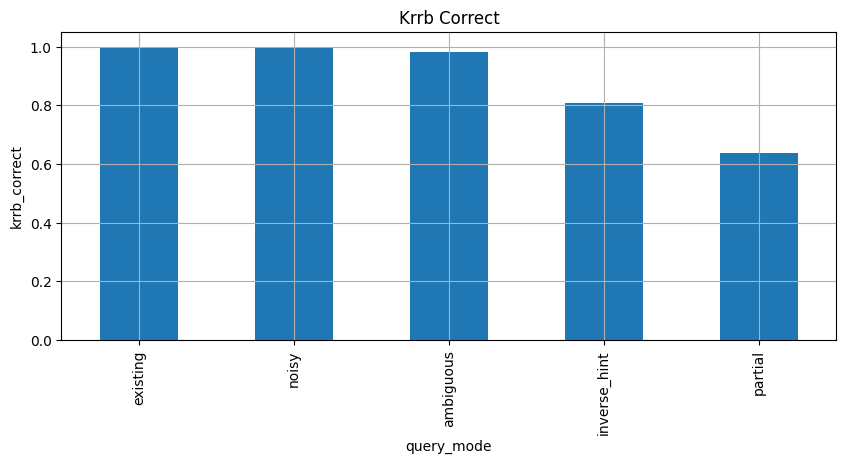

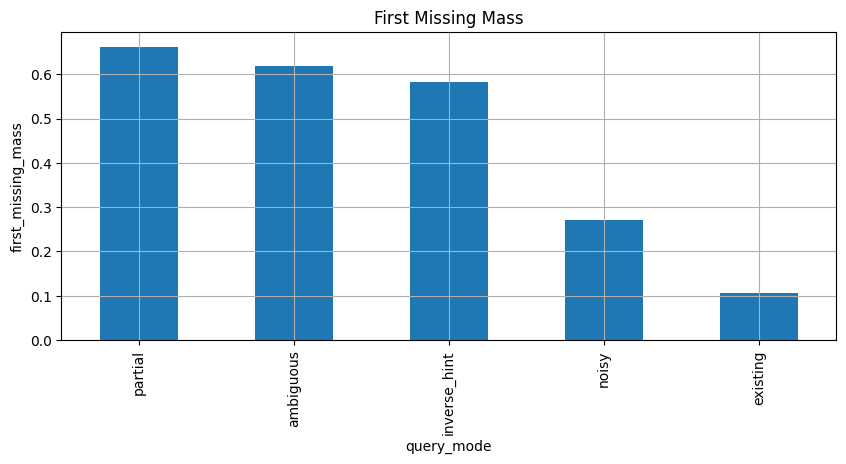

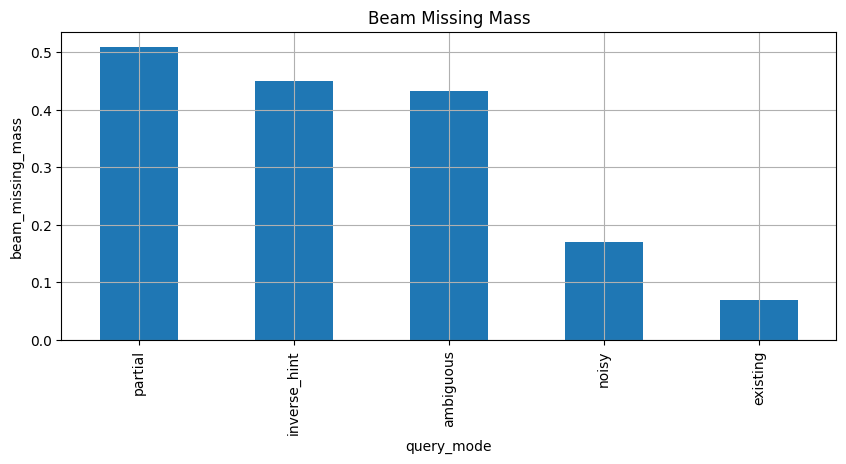

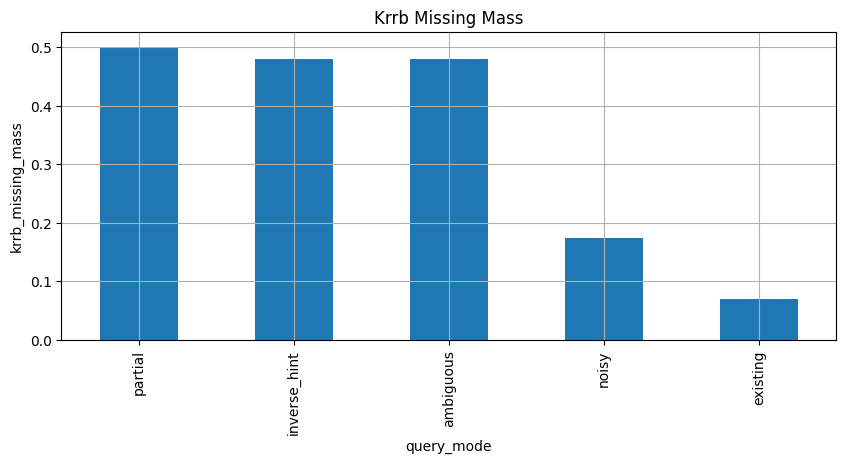

In [18]:

metrics = [
    "first_correct",
    "single_correct",
    "beam_correct",
    "krrb_correct",
    "first_missing_mass",
    "beam_missing_mass",
    "krrb_missing_mass",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()


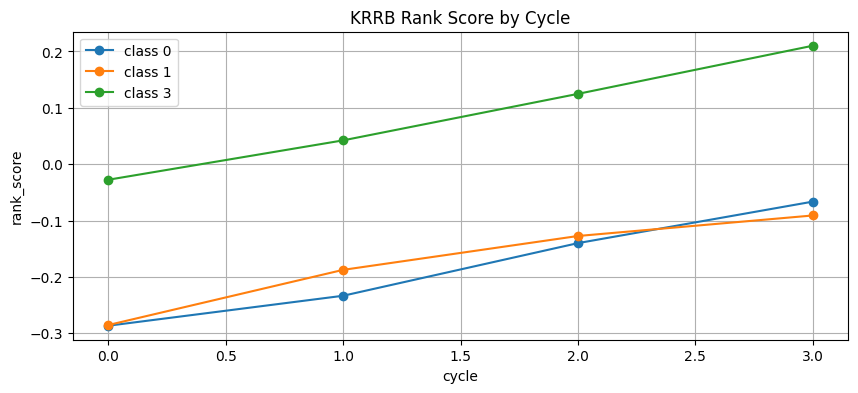

In [19]:

plt.figure(figsize=(10, 4))
for cls in sorted(krrb_trace_df["class"].unique()):
    df = krrb_trace_df[krrb_trace_df["class"] == cls]
    plt.plot(df["cycle"], df["rank_score"], marker="o", label=f"class {cls}")
plt.title("KRRB Rank Score by Cycle")
plt.xlabel("cycle")
plt.ylabel("rank_score")
plt.legend()
plt.show()



## Practical readout

This notebook makes the controller stack explicit:

- KRRB = branch ontology
- SILR = leak gate
- Samson = timing law
- AHRC = expansion law

The first tables to read are:

- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `krrb_trace_df`

The first question is:
does KRRB beat the plain beam?

The second question is:
does it help the hardest mode, `partial`?
